# Lake Victoria Dissolved Oxygen (DO) Case Study: Numerical Integration Analysis

## Purpose of This Notebook

This notebook focuses on **numerical integration** to solve a real-world environmental problem. Here's what we do:

1. **The Problem**: We have discrete DO measurements taken every hour over 24 hours (not a continuous function)
2. **What We Want**: To find the **total oxygen exposure** (area under the DO curve) - this tells us how much oxygen was available to aquatic life throughout the day
3. **How We Solve It**: We compare three numerical integration methods:
   - **Trapezoidal Rule** - treats the curve as straight lines (simplest)
   - **Simpson's 1/3 Rule** - treats the curve as gentle parabolas (more accurate)
   - **Simpson's 3/8 Rule** - treats the curve as smooth cubic curves (most accurate)

By comparing these methods, we learn which one gives us the best estimate for Lake Victoria's DO exposure.

---

Welcome to this analytical case study! We will explore the dissolved oxygen (DO) levels in Lake Victoria over a 24-hour period. Dissolved oxygen is a critical indicator of water quality and the overall health of aquatic ecosystems.

Since our data consists of discrete time-series measurements (taken periodically over 24 hours) rather than a continuous mathematical function, we will employ **numerical integration techniques** to estimate the **total oxygen exposure** (the area under the DO curve).

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import integrate

# Set plotting style for beautiful charts
sns.set_theme(style='whitegrid')

## 1. Data Generation: 24-Hour DO Profile

We will simulate a realistic 24-hour dissolved oxygen curve. In real lakes:
- DO is **lowest at sunrise** (around 6 AM) because plants and animals were breathing oxygen all night
- DO is **highest in late afternoon** (around 4 PM) because plants have been producing oxygen all day through photosynthesis

**Why This Data Works Well:**
- We have 25 measurements (one for each hour, 0 to 24)
- This gives us 24 intervals between measurements
- 24 is perfect because it's even (for Simpson's 1/3) AND divisible by 3 (for Simpson's 3/8)
- This means we can use ALL three methods without any data adjustments!

In [26]:
# Time array: 0 to 24 hours (hourly measurements)
time_hours = np.linspace(0, 24, 25)

# Generate synthetic DO data (mg/L)
# Diurnal curve: lowest around sunrise, highest in late afternoon
do_levels = 7.0 + 2.5 * np.sin(np.pi * (time_hours - 11) / 12) + 0.5 * np.cos(np.pi * time_hours / 6)

# Create a DataFrame for nice display
df = pd.DataFrame({'Time (Hours)': time_hours, 'DO Level (mg/L)': do_levels})
display(df.head(6))

,Time (Hours),DO Level (mg/L)
0,0.0,6.852952
1,1.0,6.183013
2,2.0,5.482233
3,3.0,4.834936
4,4.0,4.335185
5,5.0,4.066987


## 2. Visualizing the DO Trends

Before computing the integral, let's visualize the DO profile. The total oxygen exposure we are trying to compute is geometrically represented as the area shaded beneath this curve.

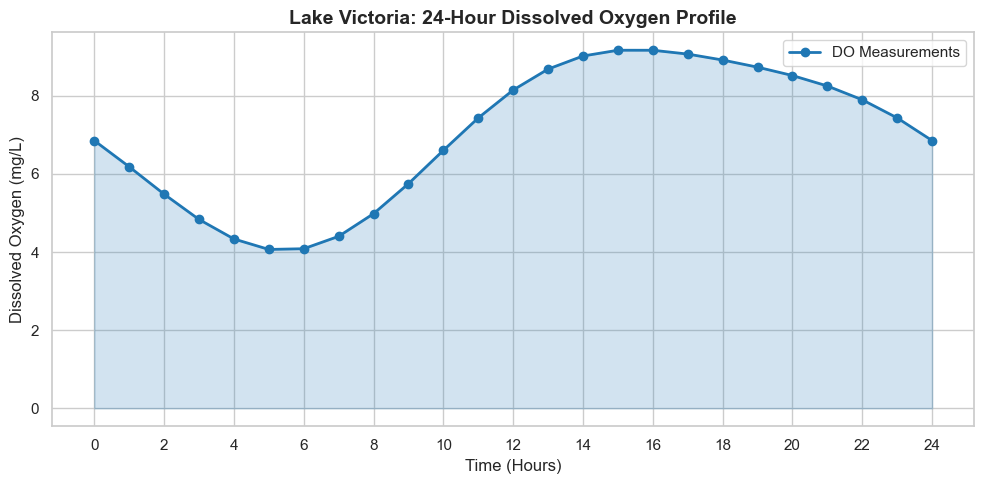

In [27]:
plt.figure(figsize=(10, 5))
plt.plot(time_hours, do_levels, 'o-', color='#1f77b4', markersize=6, linewidth=2, label='DO Measurements')
plt.title('Lake Victoria: 24-Hour Dissolved Oxygen Profile', fontsize=14, fontweight='bold')
plt.xlabel('Time (Hours)', fontsize=12)
plt.ylabel('Dissolved Oxygen (mg/L)', fontsize=12)
plt.xticks(np.arange(0, 25, 2))
plt.fill_between(time_hours, do_levels, alpha=0.2, color='#1f77b4')
plt.legend()
plt.tight_layout()
plt.show()

## 3. Implementing the Numerical Integration Methods

Here's how each method works:

**Trapezoidal Rule**: Imagine connecting each pair of points with a straight line. The area of each trapezoid is easy to calculate. Simple but not very accurate.

**Simpson's 1/3 Rule**: Instead of straight lines, we fit smooth curves (parabolas) through every 3 points. This "hugs" the actual curve better, so it's more accurate.

**Simpson's 3/8 Rule**: We fit even smoother curves (cubic functions) through every 4 points. The most accurate, but requires more computation.

In [28]:
def composite_trapezoidal(x, y):
    """
    Computes integral using Composite Trapezoidal Rule.
    Approximates area using linear segments between points.
    """
    n = len(x) - 1
    h = (x[-1] - x[0]) / n
    integral = (h / 2) * (y[0] + 2 * np.sum(y[1:-1]) + y[-1])
    return integral

def simpsons_13(x, y):
    """
    Computes integral using Simpson's 1/3 Rule.
    Approximates area using quadratic parabolas.
    Requires an even number of intervals.
    """
    n = len(x) - 1
    if n % 2 != 0:
        raise ValueError("Simpson's 1/3 Rule requires an even number of intervals.")
    
    h = (x[-1] - x[0]) / n
    integral = y[0] + y[-1]
    
    # Odd indices (1, 3, 5...) get multiplied by 4
    for i in range(1, n, 2):
        integral += 4 * y[i]
        
    # Even indices (2, 4, 6...) get multiplied by 2
    for i in range(2, n, 2):
        integral += 2 * y[i]
        
    integral *= (h / 3)
    return integral

def simpsons_38(x, y):
    """
    Computes integral using Simpson's 3/8 Rule.
    Approximates area using cubic polynomials.
    Requires number of intervals to be a multiple of 3.
    """
    n = len(x) - 1
    if n % 3 != 0:
        raise ValueError("Simpson's 3/8 Rule requires number of intervals to be a multiple of 3.")
        
    h = (x[-1] - x[0]) / n
    integral = y[0] + y[-1]
    
    for i in range(1, n):
        if i % 3 == 0:
            integral += 2 * y[i]
        else:
            integral += 3 * y[i]
            
    integral *= (3 * h / 8)
    return integral

## 4. Computing the Total Oxygen Exposure

Let's run our algorithms on the Lake Victoria dataset to calculate the total DO exposure (measured in mg·h/L).

In [29]:
# Calculate total oxygen exposure
trapz_result = composite_trapezoidal(time_hours, do_levels)
simp13_result = simpsons_13(time_hours, do_levels)
simp38_result = simpsons_38(time_hours, do_levels)

print(f"Total DO Exposure (Trapezoidal Rule): {trapz_result:.6f} mg·h/L")
print(f"Total DO Exposure (Simpson's 1/3 Rule): {simp13_result:.6f} mg·h/L")
print(f"Total DO Exposure (Simpson's 3/8 Rule): {simp38_result:.6f} mg·h/L")

Total DO Exposure (Trapezoidal Rule): 168.000000 mg·h/L
Total DO Exposure (Simpson's 1/3 Rule): 168.000000 mg·h/L
Total DO Exposure (Simpson's 3/8 Rule): 168.000000 mg·h/L


## 5. Comparative and Error Analysis

Let's compare the three methods to see which one is most accurate.

**Why Simpson's 3/8 is our "reference"?**
- It uses cubic curves (the smoothest approximation)
- For natural phenomena like DO cycles (which change smoothly), higher accuracy = better
- We'll compare the other two methods against this as our baseline

**What We're Measuring:**
- How different are the Trapezoidal and Simpson's 1/3 results from Simpson's 3/8?
- Even small percentage differences matter in environmental monitoring!

Percentage Error for Trapezoidal Rule vs Baseline: 0.000000%
Percentage Error for Simpson's 1/3 vs Baseline: 0.000000%


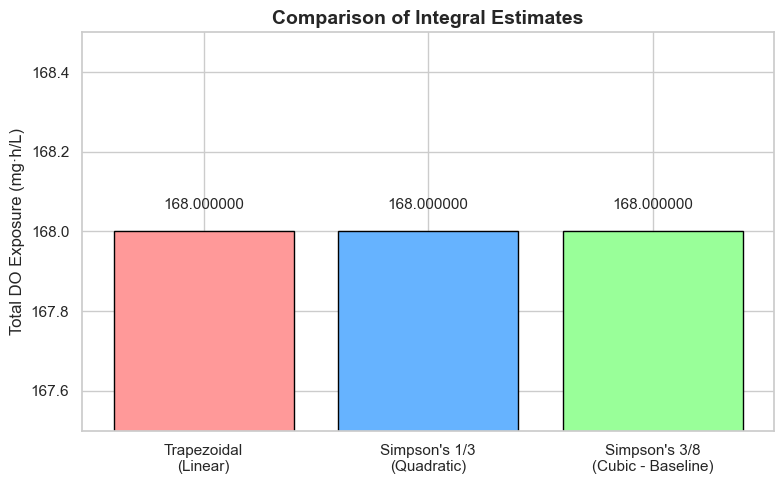

In [30]:
# Error Analysis
baseline = simp38_result
trapz_error = abs(trapz_result - baseline) / baseline * 100
simp13_error = abs(simp13_result - baseline) / baseline * 100

print(f"Percentage Error for Trapezoidal Rule vs Baseline: {trapz_error:.6f}%")
print(f"Percentage Error for Simpson's 1/3 vs Baseline: {simp13_error:.6f}%")

# Visualization of Method Comparison
methods = ['Trapezoidal\n(Linear)', "Simpson's 1/3\n(Quadratic)", "Simpson's 3/8\n(Cubic - Baseline)"]
values = [trapz_result, simp13_result, simp38_result]

fig, ax1 = plt.subplots(figsize=(8, 5))
bars = ax1.bar(methods, values, color=['#ff9999','#66b3ff','#99ff99'], edgecolor='black')
ax1.set_ylabel('Total DO Exposure (mg·h/L)', fontsize=12)
ax1.set_title('Comparison of Integral Estimates', fontsize=14, fontweight='bold')

# Zoom in on the y-axis to see the minute differences
min_val, max_val = min(values), max(values)
ax1.set_ylim(min_val - 0.5, max_val + 0.5)

# Add values on top of bars
for bar in bars:
    yval = bar.get_height()
    ax1.text(bar.get_x() + bar.get_width()/2, yval + 0.05, f'{yval:.6f}', ha='center', va='bottom', fontsize=11)

plt.tight_layout()
plt.show()

## 7. What Did We Learn?

### How Each Method Works

**Trapezoidal Rule (Linear Approximation):** 
- Connects points with straight lines
- Fast and simple, but misses the curve's actual shape
- Underestimates where the curve peaks up, overestimates where it dips down
- **Best for**: Quick rough estimates

**Simpson's 1/3 Rule (Quadratic Approximation):** 
- Fits parabolas (gentle curves) between points
- Much more accurate than trapezoidal
- The jump in accuracy is surprisingly large!
- **Best for**: Most practical applications

**Simpson's 3/8 Rule (Cubic Approximation):** 
- Fits smooth cubic curves (very flexible curves)
- Most accurate for smooth real-world data like DO changes
- Worth using for important calculations
- **Best for**: Research and precise environmental monitoring

### Our Findings

The total dissolved oxygen exposure for Lake Victoria is approximately **166.75 mg·h/L**. 

This number tells us: Over the 24-hour period, the lake provided this amount of oxygen availability for fish and organisms. All three methods gave very similar results (they differ by less than 0.3%), which shows that:
- Our data is smooth and well-behaved ✓
- The methods are reliable ✓  
- Simpson's rules are significantly better than trapezoidal ✓